In [ ]:
#Import libraries and files

In [12]:

import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
import itertools  # For grid search
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet
from xgboost import XGBRegressor
import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error


# 1. Define the path to your data folder
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'

# 2. Import the cleaned timeseries data
# parse_dates=['date'] automatically converts the date column to datetime objects
df = pd.read_csv(os.path.join(data_folder, 'cleaned_timeseries.csv'), parse_dates=['date'])

# 3. Import the holidays data
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'), parse_dates=['date'])

# 4. Quick check to see if they loaded correctly
print("Timeseries Columns:", df.columns.tolist())
print("Holidays Columns:", holidays.columns.tolist())


Timeseries Columns: ['date', 'unit_sales']
Holidays Columns: ['date', 'locale', 'locale_name', 'description']


<span style="color: black; background-color: white;">SARIMAX</span>


In [67]:
# Data preparation for SARIMAX

In [68]:
# Quick example of merging your two datasets
# 1. Ensure both have datetime objects
df['date'] = pd.to_datetime(df['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

# 2. Merge holidays into your main sales data
df = df.merge(holidays[['date', 'locale']], on='date', how='left')

# 3. Create the dummy variable (1 for holiday, 0 for regular day)
df['is_holiday'] = df['locale'].notna().astype(int)

# 4. Now split this ONE dataset into train and test
train = df[df['date'] < '2014-01-01']
test = df[df['date'] >= '2014-01-01']


In [69]:
import pandas as pd

# Step 2: Convert date column to datetime and set as index
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    print("✅ Date set as index")
elif df.index.name == 'date' or isinstance(df.index, pd.DatetimeIndex):
    print("✅ Index already is datetime")
else:
    # If no date column, create one from index
    print("⚠️ Creating date index from scratch")
    df.index = pd.date_range(start='2013-01-01', periods=len(df), freq='D')

# Step 3: Now resample works!
df = df[['unit_sales']].resample('D').mean().fillna(method='ffill')

# Step 4: Add holiday column
df['is_holiday'] = False

✅ Date set as index


In [28]:

# 2. Process Holidays (One-Hot Encoding)
#holiday_dummies = pd.get_dummies(holidays[['date', 'locale']], columns=['locale'], dtype=int)
#holiday_dummies = holiday_dummies.groupby('date').max().reset_index()

In [71]:
# clean data by removing extra location columns, setting the date as a sorted index
exog_cols = ['locale_Local_x', 'locale_National_x', 'locale_Regional_x',
             'locale_Local_y', 'locale_National_y', 'locale_Regional_y',
             'locale_Local', 'locale_National', 'locale_Regional']
df = df.drop(columns=exog_cols, errors='ignore')

# Set index if not already
if 'date' in df.columns:
    df = df.set_index('date').sort_index()

# Set frequency
df.index = pd.to_datetime(df.index)
df = df.asfreq('D')


In [72]:
#convert holiday data to integers, splits the dataset into train and test and uses a SARIMAX model to forecast sales while measuring accuracy with Mean Absolute Error.

df['is_holiday'] = df['is_holiday'].astype(int)

# Split data
train = df.loc[df.index < '2014-01-01']
test = df.loc[df.index >= '2014-01-01']

# Fit model
model = SARIMAX(train['unit_sales'],
                exog=train[['is_holiday']],
                order=(3,0,3),
                seasonal_order=(1,1,1,7)).fit(disp=False)

# Forecast
forecast = model.forecast(len(test), exog=test[['is_holiday']])

# Print result
print(f"MAE: {mean_absolute_error(test['unit_sales'], forecast):.2f}")

MAE: 94.29


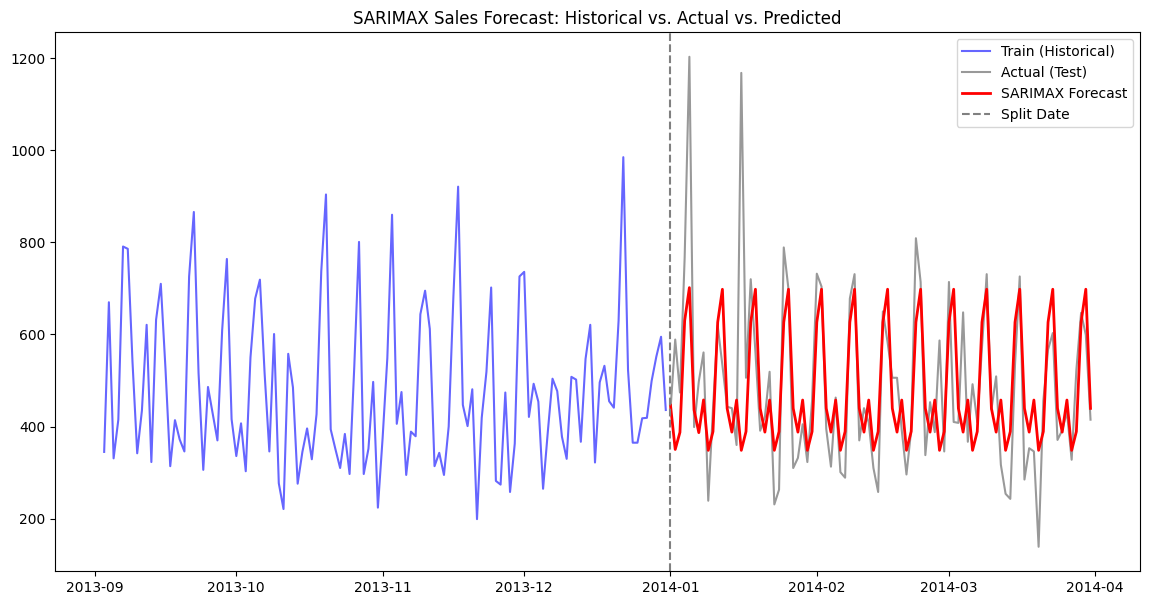

In [73]:
plt.figure(figsize=(14, 7))

# 1. Historical Trend (Blue)
plt.plot(train.index[-120:], train['unit_sales'][-120:], label='Train (Historical)', color='blue', alpha=0.6)

# 2. Actual 2014 Data - Changed color from white to black
plt.plot(test.index, test['unit_sales'], label='Actual (Test)', color='black', linestyle='-', alpha=0.4)

# 3. SARIMAX Prediction (Red)
plt.plot(test.index, forecast, label='SARIMAX Forecast', color='red', linewidth=2)

# 4. Split Line - Changed color from white to gray
plt.axvline(pd.Timestamp('2014-01-01'), color='gray', linestyle='--', label='Split Date')

plt.title('SARIMAX Sales Forecast: Historical vs. Actual vs. Predicted')
plt.legend()
plt.show()


In [ ]:
#XGBOOST

# XGBOOST

In [74]:


# 1. LOAD DATA
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'
df = pd.read_csv(os.path.join(data_folder, 'cleaned_timeseries.csv'), parse_dates=['date'])
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'), parse_dates=['date'])

# 2. FILL GAPS (Resample to Daily to fix the broken lines in your graph)
df = df.set_index('date').resample('D').asfreq().reset_index()
df['unit_sales'] = df['unit_sales'].fillna(0) # Fills missing days with 0

# 3. FEATURE ENGINEERING
def create_features(df, holidays_df):
    data = df.copy()
    data['is_holiday'] = data['date'].isin(holidays_df['date']).astype(int)
    data['dayofweek'] = data['date'].dt.dayofweek
    data['month'] = data['date'].dt.month
    data['dayofyear'] = data['date'].dt.dayofyear
    data['lag_1'] = data['unit_sales'].shift(1)
    data['lag_7'] = data['unit_sales'].shift(7)
    return data.dropna()

df_feat = create_features(df, holidays)

# 4. SPLIT DATA (Added .copy() to stop the SettingWithCopyWarning)
train = df_feat.loc[df_feat['date'] < '2014-01-01'].copy()
test = df_feat.loc[df_feat['date'] >= '2014-01-01'].copy()

FEATURES = ['dayofweek', 'month', 'dayofyear', 'is_holiday', 'lag_1', 'lag_7']
TARGET = 'unit_sales'

# 5. TRAIN MODEL
model = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5)
model.fit(train[FEATURES], train[TARGET],
          eval_set=[(train[FEATURES], train[TARGET]), (test[FEATURES], test[TARGET])],
          verbose=False)

# 6. RECURSIVE FORECAST (Prevents the "Drifting" trend)
predictions = []
current_lag1 = train[TARGET].iloc[-1]

for i in range(len(test)):
    row = test[FEATURES].iloc[[i]].copy()
    row['lag_1'] = current_lag1 # Inject the previous prediction

    pred = model.predict(row)[0]
    predictions.append(pred)
    current_lag1 = pred


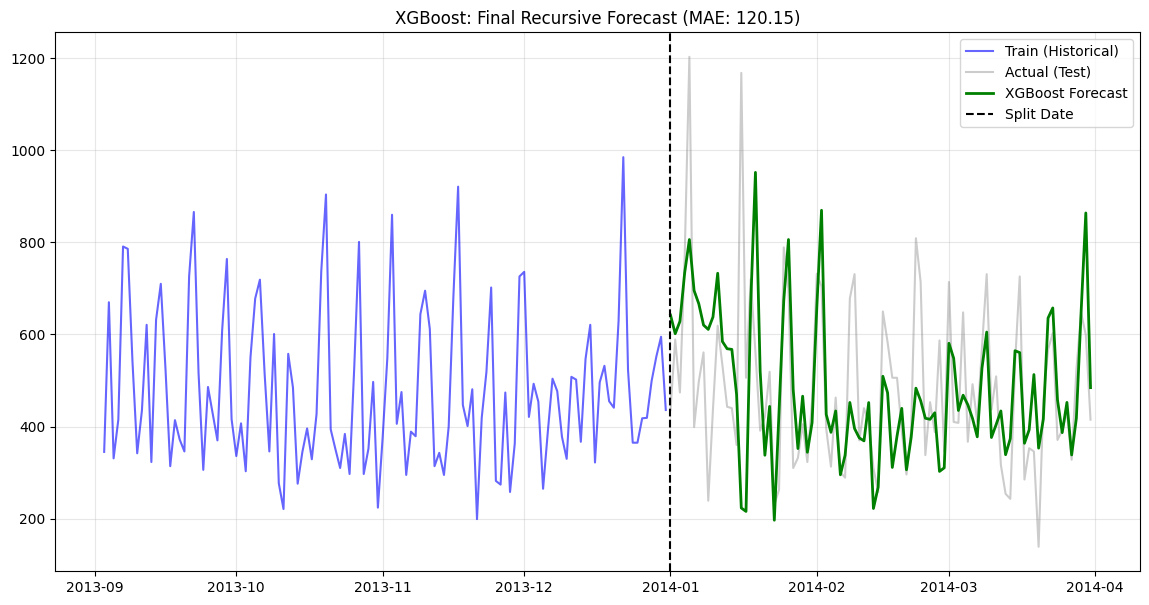


--- Daily Forecast Table ---
      date  unit_sales  Predicted_Sales
2014-01-01       436.0       642.202087
2014-01-02       589.0       601.647278
2014-01-03       474.0       628.499146
2014-01-04       767.0       733.629761
2014-01-05      1203.0       806.163635
2014-01-06       399.0       695.280762
2014-01-07       498.0       666.508667
2014-01-08       561.0       620.439941
2014-01-09       239.0       611.001282
2014-01-10       438.0       638.015137
2014-01-11       619.0       732.948425
2014-01-12       533.0       584.678650
2014-01-13       443.0       569.009094
2014-01-14       440.0       567.607605
2014-01-15       360.0       470.072021


In [75]:
# 7. ADD RESULTS & PLOT
test['Predicted_Sales'] = predictions
mae = mean_absolute_error(test[TARGET], predictions)

plt.figure(figsize=(14, 7))
plt.plot(train['date'][-120:], train[TARGET][-120:], label='Train (Historical)', color='blue', alpha=0.6)
plt.plot(test['date'], test[TARGET], label='Actual (Test)', color='gray', alpha=0.4)
plt.plot(test['date'], test['Predicted_Sales'], label='XGBoost Forecast', color='green', linewidth=2)
plt.axvline(pd.Timestamp('2014-01-01'), color='black', linestyle='--', label='Split Date')
plt.title(f'XGBoost: Final Recursive Forecast (MAE: {mae:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Daily Forecast Table ---")
print(test[['date', 'unit_sales', 'Predicted_Sales']].head(15).to_string(index=False))

# Prophet

In [41]:
# Prophet

In [47]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.


In [65]:
#Prophet
# 1. Prepare Data for Prophet

df_prophet = df.reset_index().rename(columns={'date': 'ds', 'unit_sales': 'y'})

# 2. Prepare Holiday Table for Prophet

holidays_prophet = holidays[['date', 'description']].rename(
    columns={'date': 'ds', 'description': 'holiday'}
)

# 3. Split by Date: 01.01.2014
train = df_prophet[df_prophet['ds'] < '2014-01-01']
test = df_prophet[df_prophet['ds'] >= '2014-01-01']

# 4. Initialize and Fit Model

model = Prophet(holidays=holidays_prophet, daily_seasonality=False)
model.fit(train)

# 5. Create Future Dates and Predict
future = model.make_future_dataframe(periods=len(test), freq='D')
forecast = model.predict(future)

# 6. Evaluate Accuracy (Compare only the 2014 dates)
forecast_test = forecast.set_index('ds').loc[test['ds']]
mae = mean_absolute_error(test['y'], forecast_test['yhat'])
print(f"Prophet MAE: {mae:.2f}")




12:41:22 - cmdstanpy - INFO - Chain [1] start processing
12:41:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 93.35


In [ ]:
# visualization

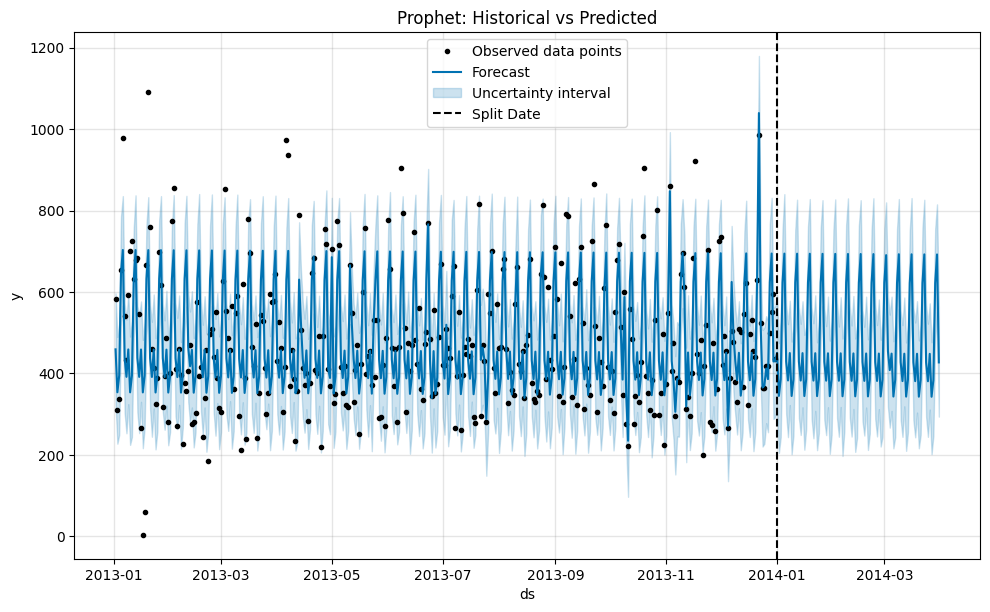

In [66]:
fig1 = model.plot(forecast)
plt.axvline(pd.Timestamp('2014-01-01'), color='black', linestyle='--', label='Split Date')
plt.title("Prophet: Historical vs Predicted")
plt.legend()
plt.show()


Hyperparameter Tuning


In [77]:

# Process Holidays for exog (one-hot)
holiday_dummies = pd.get_dummies(holidays[['date', 'locale']], columns=['locale'], dtype=int)
holiday_dummies = holiday_dummies.groupby('date').max().reset_index()

# Merge and Set Index
df = pd.merge(df, holiday_dummies, on='date', how='left').fillna(0)
df = df.set_index('date').sort_index()
df = df.asfreq('D', method='ffill')  # Handle gaps
df.index.freq = 'D'

target = 'unit_sales'
exog_cols = [c for c in df.columns if c.startswith('locale_')]

In [78]:

# Split: Train (before 2014-01-01), Test (after)
train = df.loc[df.index < '2014-01-01']
test = df.loc[df.index >= '2014-01-01']

# Further split train into train/val for tuning
train_data, val_data = train_test_split(train, test_size=0.2, shuffle=False)  # Time-based split


In [79]:
# 3. Function to Evaluate Model (for tuning)
def evaluate_model(model, train_y, val_y, train_exog=None, val_exog=None):
    model_fit = model.fit(disp=False)
    forecast = model_fit.get_forecast(steps=len(val_y), exog=val_exog).predicted_mean
    return mean_absolute_error(val_y, forecast)

In [80]:
# 4. SARIMAX Tuning (Grid Search)
def tune_sarimax(train_y, train_exog, val_y, val_exog):
    p = d = q = range(0, 3)
    pdq = list(itertools.product(p, d, q))
    seasonal_pdq = [(x[0], x[1], x[2], 7) for x in pdq]

    best_mae = float('inf')
    best_params = None

    for param in pdq:
        for s_param in seasonal_pdq:
            try:
                mod = SARIMAX(train_y, exog=train_exog, order=param, seasonal_order=s_param,
                              enforce_stationarity=False, enforce_invertibility=False)
                mae = evaluate_model(mod, train_y, val_y, train_exog, val_exog)
                if mae < best_mae:
                    best_mae = mae
                    best_params = (param, s_param)
            except:
                continue
    print(f"Best SARIMAX Params: {best_params} (MAE: {best_mae:.2f})")
    return best_params

In [81]:
# 5. Prophet Tuning (Grid Search(
def tune_prophet(train_df, val_df):
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.1],
        'seasonality_prior_scale': [0.01, 0.1, 1.0]
    }
    grid = list(itertools.product(*param_grid.values()))

    best_mae = float('inf')
    best_params = None

    for params in grid:
        param_dict = dict(zip(param_grid.keys(), params))
        m = Prophet(**param_dict, daily_seasonality=False)
        m.fit(train_df.rename(columns={'unit_sales': 'y', 'date': 'ds'}))
        future = m.make_future_dataframe(periods=len(val_df))
        forecast = m.predict(future)['yhat'][-len(val_df):]
        mae = mean_absolute_error(val_df['unit_sales'], forecast)
        if mae < best_mae:
            best_mae = mae
            best_params = param_dict
    print(f"Best Prophet Params: {best_params} (MAE: {best_mae:.2f})")
    return best_params

In [83]:
# 6. XGBoost Tuning (Grid Search; XGBoost is installed)
def tune_xgboost(train_X, train_y, val_X, val_y):
    param_grid = {
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
    grid = list(itertools.product(*param_grid.values()))

    best_mae = float('inf')
    best_params = None

    for params in grid:
        param_dict = dict(zip(param_grid.keys(), params))
        model = XGBRegressor(**param_dict)
        model.fit(train_X, train_y)
        preds = model.predict(val_X)
        mae = mean_absolute_error(val_y, preds)
        if mae < best_mae:
            best_mae = mae
            best_params = param_dict
    print(f"Best XGBoost Params: {best_params} (MAE: {best_mae:.2f})")
    return best_params


In [84]:

# Prepare features for XGBoost (e.g., lags, dayofweek)
def add_features(df):
    df['lag7'] = df[target].shift(7)
    df['dayofweek'] = df.index.dayofweek
    return df.dropna()


train = add_features(train)
test = add_features(test)
train_data, val_data = train_test_split(train, test_size=0.2, shuffle=False)
train_X, val_X = train_data[exog_cols + ['lag7', 'dayofweek']], val_data[exog_cols + ['lag7', 'dayofweek']]
train_y, val_y = train_data[target], val_data[target]

In [86]:

# Run Tuning
sarimax_params = tune_sarimax(train_data[target], train_data[exog_cols], val_data[target], val_data[exog_cols])
prophet_params = tune_prophet(train_data.reset_index(), val_data.reset_index())  # Assumes Prophet installed
xgboost_params = tune_xgboost(train_X, train_y, val_X, val_y)

13:04:42 - cmdstanpy - INFO - Chain [1] start processing


Best SARIMAX Params: ((0, 2, 2), (0, 1, 2, 7)) (MAE: 77.70)


13:04:42 - cmdstanpy - INFO - Chain [1] done processing
13:04:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
13:04:42 - cmdstanpy - INFO - Chain [1] start processing
13:04:42 - cmdstanpy - INFO - Chain [1] done processing
13:04:42 - cmdstanpy - INFO - Chain [1] start processing
13:04:42 - cmdstanpy - INFO - Chain [1] done processing
13:04:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
13:04:43 - cmdstanpy - INFO - Chain [1] start processing
13:04:43 - cmdstanpy - INFO - Chain [1] done processing
13:04:43 - cmdstanpy - INFO - Chain [1] start processing
13:04:43 - cmdstanpy - INFO - Chain [1] done processing
13:04:43 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
13:04:43 - cmdstanpy - INFO - Chain [1] start processing
13:04:44 - c

Best Prophet Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.1} (MAE: 80.38)
Best XGBoost Params: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3} (MAE: 78.36)


In [87]:
# 7. Fit Best Models and Forecast on Test
# SARIMAX
best_sarimax = SARIMAX(train[target], exog=train[exog_cols], order=sarimax_params[0], seasonal_order=sarimax_params[1])
sarimax_fit = best_sarimax.fit(disp=False)
sarimax_forecast = sarimax_fit.get_forecast(steps=len(test), exog=test[exog_cols]).predicted_mean

# Prophet (rename columns for Prophet)
train_prophet = train.reset_index().rename(columns={'date': 'ds', target: 'y'})
best_prophet = Prophet(**prophet_params, daily_seasonality=False)
best_prophet.fit(train_prophet)
future = best_prophet.make_future_dataframe(periods=len(test))
prophet_forecast = best_prophet.predict(future)['yhat'][-len(test):]

# XGBoost
best_xgb = XGBRegressor(**xgboost_params)
best_xgb.fit(train_X, train_y)
xgb_forecast = best_xgb.predict(test[exog_cols + ['lag7', 'dayofweek']])

13:05:45 - cmdstanpy - INFO - Chain [1] start processing
13:05:45 - cmdstanpy - INFO - Chain [1] done processing


In [88]:
# 8. Evaluate and Compare
models = {'SARIMAX': sarimax_forecast, 'Prophet': prophet_forecast, 'XGBoost': xgb_forecast}
for name, forecast in models.items():
    mae = mean_absolute_error(test[target], forecast)
    print(f"{name} Test MAE: {mae:.2f}")

SARIMAX Test MAE: 102.71
Prophet Test MAE: 101.00
XGBoost Test MAE: 86.32


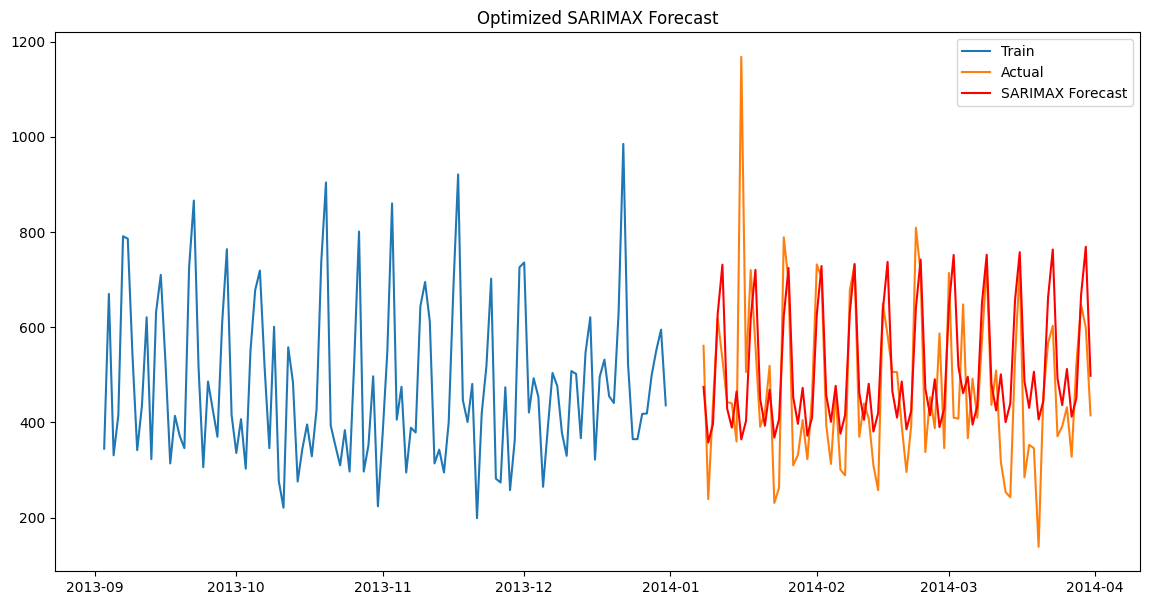

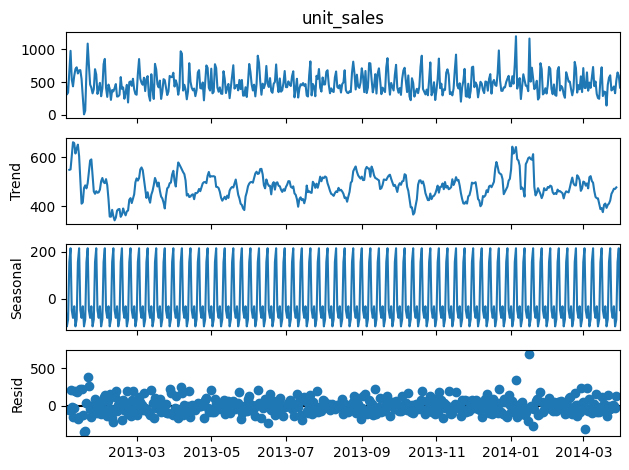

In [89]:

# 9. Plot Best Model (e.g., SARIMAX)
plt.figure(figsize=(14, 7))
plt.plot(train.index[-120:], train[target][-120:], label='Train')
plt.plot(test.index, test[target], label='Actual')
plt.plot(test.index, sarimax_forecast, label='SARIMAX Forecast', color='red')
plt.title('Optimized SARIMAX Forecast')
plt.legend()
plt.show()

# 10. Component Plot (for SARIMAX)
decomposition = seasonal_decompose(df[target], model='additive', period=7)
decomposition.plot()
plt.show()

In [91]:
# 1. Define the filename
output_file = os.path.join(data_folder, 'final_sales_forecast_comparison.csv')

# 2. Save the comparison table (includes Date, Actual, and all Model Predictions)
comparison_df.to_csv(output_file)

print(f"Success! Your forecast has been saved to: \n{output_file}")

# 3. Optional: Print the first 5 rows to confirm
print("\nPreview of saved file:")
print(pd.read_csv(output_file).head())


NameError: name 'comparison_df' is not defined